In [1]:
import sys
sys.path.append('../../')
from DEDi import PDE_find as PDE
import numpy as np
import matplotlib.pyplot as plt
import time
import jax.numpy as jnp

### Allen-Cahn Equation

$(a,b,c) = (1,1,-1)$

$$u_t  = a \Delta u + u + c u^3 $$

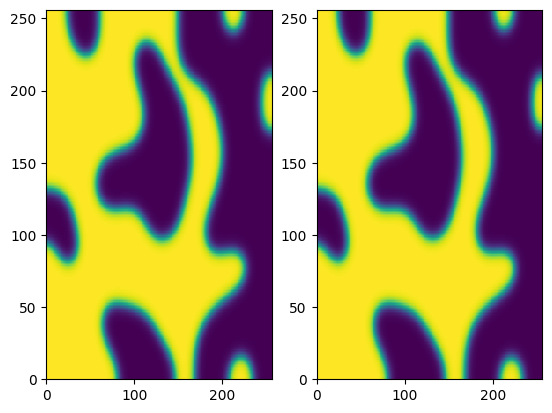

(2, 256, 256)


In [2]:
from scipy.fft import dctn, idctn

# Allen-Cahn equation u_t = Δu + u - u^3 with Neumann BCs
# Iterative Convexity Splitting using linear extrapolation for predictor.

# Spatial dimensions, grid
np.random.seed(1)

sf = 1  # scaling factor
N = sf * 256
M = sf * 256
dx = 40.0 / (128 - 1)
dx2 = dx ** 2
x = np.linspace(dx * 0.5, dx * (N - 0.5), N)
y = np.linspace(dx * 0.5, dx * (M - 0.5), M)
X, Y = np.meshgrid(x, y)
dt = 1e-2

# Unscaled eigenvalues of the Laplacian (Neumann BC)
Leig = (2 * np.cos(np.pi * np.arange(N) / (N - 1)) - 2)[..., np.newaxis] + \
       (2 * np.cos(np.pi * np.arange(M) / (M - 1)) - 2)

# Scaled eigenvalues of the Laplacian (Neumann BC)
Lap = Leig / dx2

U = .1 * (np.random.rand(N, M) - 0.5)  # Initial condition, slight asymmetric phase fraction
hat_U = dctn(U, norm='ortho')  # Transform

# Main loop
Uold = U
it = 0
t = 0.0
Udata = np.zeros((N, M, 2))  # For capturing data points
times = np.zeros(2)

i = 0
while t < 30:
    U1 = 2 * U - Uold  # Linear extrapolation
    hat_rhs = hat_U + dt * dctn(2 * U1 - U1 * U1 * U1, norm='ortho')
    hat_U1 = hat_rhs / (1 - dt * (Lap - 1))
    U1 = idctn(hat_U1, norm='ortho')
    Uold, U, hat_U = U, U1, hat_U1
    it += 1
    t += dt

    # Capture data points
    if 25 <= t <= 25 + dt:
        times[0] = t
        Udata[:, :, 0] = U
    if 26 <= t and times[1] == 0:
        times[1] = t
        Udata[:, :, 1] = U

# Plot captured data points
plt.subplot(1, 2, 1)
plt.pcolor(Udata[:, :, 0], shading='auto')
plt.subplot(1, 2, 2)
plt.pcolor(Udata[:, :, 1], shading='auto')
plt.show()

u_total = Udata.transpose(2, 0, 1)

percent_noise = 0.1
u_noise = u_total + np.random.normal(0,np.std(u_total)*percent_noise,size=u_total.shape)
print(np.shape(u_noise))

In [3]:
# If you want to mask the states
FractionOfDataMissing = 0.0
NumOfDataMissing = int(np.size(u_noise)*FractionOfDataMissing)
state_mask = np.ones(np.size(u_noise)).astype(bool)
state_mask[:NumOfDataMissing] = False
np.random.shuffle(state_mask)
state_mask = np.reshape(state_mask,np.shape(u_noise))
u_noise = u_noise*state_mask #Just to show it is truly masking this data

In [4]:
TRange, XRange, YRange = [times[0],times[-1]], [x[0],x[-1]], [y[0],y[-1]]
symbols = ['u_xx','u_yy','u','u^3','u_x','u_y','u u_x','u u_y', 'u^2 u_x','u^2 u_y']

trial = PDE(u_noise,symbols,TRange, XRange, YRange = YRange,
             state_mask=state_mask, smooth_init_states = None,
             init_params = None,
             cpu_or_gpu = 'gpu')

Setting Up Sparse Structure
Colors Needed = 54


In [5]:
objectives = [1e-2,1e-6]    
guess = trial.FindBestModel(objective_params = objectives,
                                tolerance = 1e-5,verbose=True,
                                max_iterations = 1000,method = "LM",
                                info_criteria='BIC',
                                drop_method = {"initial":'single',"k":3},
                                LA_solver = 'jax_cg')

1 | f = 4093867.867667, ||df|| = 5.734e+06, Alpha = 2.000e+01, SolverTime = 1.123s, HessianTime = 0.001s
1 | f = 4093969.907898, ||df|| = 5.734e+06, Alpha = 2.000e+01, SolverTime = 1.224s, HessianTime = 0.003s
2 | f = 2836439.819216, ||df|| = 4.128e+06, Alpha = 4.000e+00, SolverTime = 0.147s, HessianTime = 0.001s
2 | f = 2836513.097430, ||df|| = 4.128e+06, Alpha = 4.000e+00, SolverTime = 0.128s, HessianTime = 0.000s
3 | f = 1104557.383555, ||df|| = 1.670e+06, Alpha = 8.000e-01, SolverTime = 0.134s, HessianTime = 0.000s
3 | f = 1099595.262044, ||df|| = 1.666e+06, Alpha = 8.000e-01, SolverTime = 0.118s, HessianTime = 0.000s
4 | f = 277983.840987, ||df|| = 6.526e+05, Alpha = 1.600e-01, SolverTime = 0.124s, HessianTime = 0.000s
4 | f = 276650.234742, ||df|| = 6.508e+05, Alpha = 1.600e-01, SolverTime = 0.104s, HessianTime = 0.000s
5 | f = 56262.056714, ||df|| = 2.033e+05, Alpha = 3.200e-02, SolverTime = 0.115s, HessianTime = 0.000s
5 | f = 56003.807216, ||df|| = 2.028e+05, Alpha = 3.200e-02

In [6]:
models,latex = trial.PrintModels(return_latex=True,ICCutoff=0)
latex

<IPython.core.display.Latex object>

'\\begin{align*}Rel IC &= 0.0\\\\Likelyhood &= 46.95182124628945\\\\\\ u_t &= 0.864u_{xx} + 0.904u_{yy} + 0.889u - 0.889u^3 \\\\\\end{align*}'

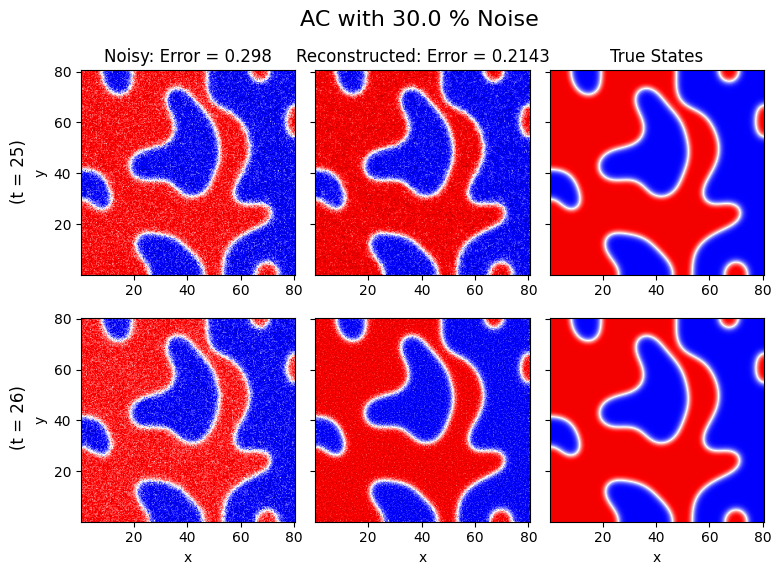

In [7]:
opt_states,opt_params = trial.unravel_states_and_parameters(trial.states_and_parameters)
state_mask = trial.state_mask
t = times

# Calculate global min and max across all data arrays for consistent coloring
min_val = min( np.min(opt_states), np.min(u_total))
max_val = max(np.max(opt_states), np.max(u_total))

fig, axs = plt.subplots(2, 3, figsize=(8, 6), sharey=True)

Noisy_error = np.linalg.norm(u_noise - u_total)/np.linalg.norm(u_total)
Reconstructed_error = np.linalg.norm(opt_states - u_total)/np.linalg.norm(u_total)

cmap = 'seismic' 

axs[0,0].imshow(u_noise[0], extent=[x[0], x[-1], x[0], x[-1]], origin='lower', aspect='auto', cmap=cmap)
axs[0,0].set_title(f'Noisy: Error = {Noisy_error:.3f}')
axs[0,0].set_ylabel('y')

axs[1,0].imshow(u_noise[1], extent=[x[0], x[-1], x[0], x[-1]], origin='lower', aspect='auto', cmap=cmap)
axs[1,0].set_xlabel('x')
axs[1,0].set_ylabel('y')

axs[0,1].imshow(opt_states[0], extent=[x[0], x[-1], x[0], x[-1]], origin='lower', aspect='auto', cmap=cmap, vmin=min_val, vmax=max_val)
axs[0,1].set_title(f'Reconstructed: Error = {Reconstructed_error:.4f}')

axs[1,1].imshow(opt_states[1], extent=[x[0], x[-1], x[0], x[-1]], origin='lower', aspect='auto', cmap=cmap, vmin=min_val, vmax=max_val)
axs[1,1].set_xlabel('x')

axs[0,2].imshow(u_total[0], extent=[x[0], x[-1], x[0], x[-1]], origin='lower', aspect='auto', cmap=cmap, vmin=min_val, vmax=max_val)
axs[0,2].set_title('True States')

axs[1,2].imshow(u_total[1], extent=[x[0], x[-1], x[0], x[-1]], origin='lower', aspect='auto', cmap=cmap, vmin=min_val, vmax=max_val)
axs[1,2].set_xlabel('x')

# Add time labels on the left side of the plot
fig.text(0.00, 0.71, '(t = 25)', fontsize=12, rotation='vertical', va='center', ha='center')
fig.text(0.00, 0.3, '(t = 26)', fontsize=12, rotation='vertical', va='center', ha='center')


plt.suptitle(f'AC with {percent_noise*100} % Noise', fontsize=16)
plt.tight_layout(rect=[0, 0.03, .95, 1])